Contoh Data

In [ ]:
import pandas as pd

data = {
    "viewers": [100, 5000, 20000, 300, 15000, 800, 7000, 25000, 120, 10000],
    "duration": [30, 120, 180, 45, 150, 60, 90, 200, 40, 130],
    "comments": [10, 800, 5000, 30, 3000, 100, 1200, 7000, 15, 2000],
    "sold": [5, 300, 2000, 10, 1500, 50, 500, 2500, 8, 900],
    "discount": [10, 40, 60, 15, 50, 20, 35, 70, 10, 45],
    "hosts": [1, 2, 3, 1, 2, 1, 2, 3, 1, 2]
}

df = pd.DataFrame(data)
df

,viewers,duration,comments,sold,discount,hosts
0,100,30,10,5,10,1
1,5000,120,800,300,40,2
2,20000,180,5000,2000,60,3
3,300,45,30,10,15,1
4,15000,150,3000,1500,50,2
5,800,60,100,50,20,1
6,7000,90,1200,500,35,2
7,25000,200,7000,2500,70,3
8,120,40,15,8,10,1
9,10000,130,2000,900,45,2


Preprocessing

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

Elbow Method

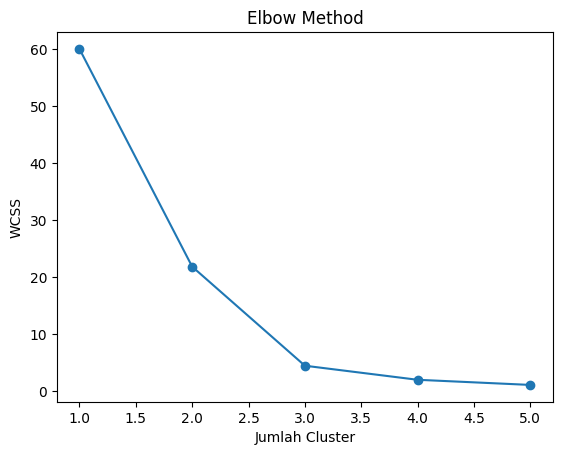

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(1, 6):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 6), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Jumlah Cluster")
plt.ylabel("WCSS")
plt.show()

Clustering

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

df

,viewers,duration,comments,sold,discount,hosts,cluster
0,100,30,10,5,10,1,0
1,5000,120,800,300,40,2,1
2,20000,180,5000,2000,60,3,2
3,300,45,30,10,15,1,0
4,15000,150,3000,1500,50,2,1
5,800,60,100,50,20,1,0
6,7000,90,1200,500,35,2,1
7,25000,200,7000,2500,70,3,2
8,120,40,15,8,10,1,0
9,10000,130,2000,900,45,2,1


Visualisasi

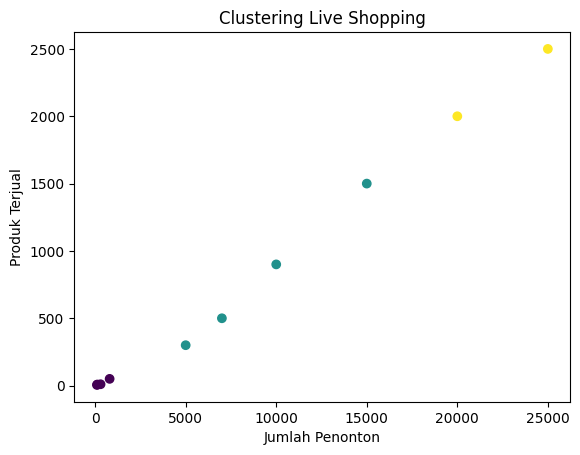

In [ ]:
plt.scatter(df['viewers'], df['sold'], c=df['cluster'])
plt.xlabel("Jumlah Penonton")
plt.ylabel("Produk Terjual")
plt.title("Clustering Live Shopping")
plt.show()